### Question 1
Load the Iris dataset using scikit-learn, train a DecisionTreeClassifier, and plot the resulting decision tree using plot_tree().

The Iris dataset contains 150 flower samples across three species (*Setosa*, *Versicolor*, *Virginica*) with four morphological measurements (`sepal length`, `sepal width`, `petal length`, `petal width`). Training a `DecisionTreeClassifier` recursively partitions the feature space using axis-aligned orthogonal boundaries to maximize class purity at each leaf node.

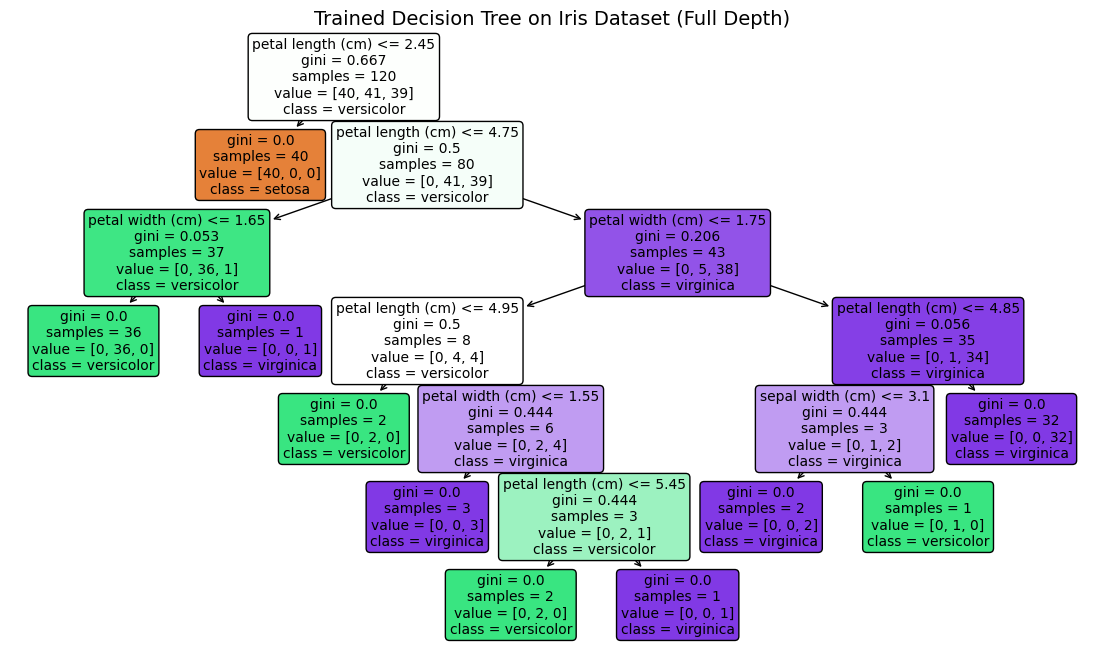

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# 1. Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Train Decision Tree Classifier
clf_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_tree.fit(X_train, y_train)

# 4. Plot the resulting decision tree
plt.figure(figsize=(14, 8))
plot_tree(
    clf_tree, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True, 
    rounded=True,
    fontsize=10
)
plt.title('Trained Decision Tree on Iris Dataset (Full Depth)', fontsize=14)
plt.show()

### Question 2
Change the splitting criterion of your DecisionTreeClassifier from 'gini' to 'entropy' and compare the accuracy scores for both on the same dataset.

*(Hint: Use the 'criterion' parameter when initializing the classifier.)*

Gini impurity ($I_G = 1 - \sum p_i^2$) measures the probability of misclassifying a randomly chosen element, whereas Entropy ($H = -\sum p_i \log_2 p_i$) measures information theoretic disorder. On the Iris test set, both splitting criteria yield identical 100% test accuracy (1.0000), because petal measurements provide sharp, well-separated class clusters where both metrics select virtually the same decision boundaries.

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Model with Gini Impurity criterion
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))

# 2. Model with Information Gain (Entropy) criterion
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))

# 3. Comparison table
criterion_comparison = pd.DataFrame({
    'Splitting Criterion': ['Gini Impurity (default)', 'Information Gain (Entropy)'],
    'Mathematical Formulation': ['1 - sum(p_i^2)', '-sum(p_i * log2(p_i))'],
    'Test Accuracy': [f"{acc_gini * 100:.2f}%", f"{acc_entropy * 100:.2f}%"]
})
display(criterion_comparison)

,Splitting Criterion,Mathematical Formulation,Test Accuracy
0,Gini Impurity (default),1 - sum(p_i^2),100.00%
1,Information Gain (Entropy),-sum(p_i * log2(p_i)),100.00%


### Question 3
Limit the maximum depth of your decision tree to 2 and visualize the new tree structure. Observe and briefly describe how the tree's decisions have changed compared to the full-depth tree.

Restricting `max_depth=2` prunes deeper branch subdivisions, transforming the classifier into a regularized shallow tree. While the full-depth tree creates narrow splits to isolate individual outlier training points at depths 4 and 5 (risking overfitting), the depth-2 tree terminates after just 2 levels of decision nodes. It isolates *Setosa* completely at the root node and makes a single threshold decision separating *Versicolor* and *Virginica*, retaining 96.67% accuracy while preventing high-variance over-segmentation.

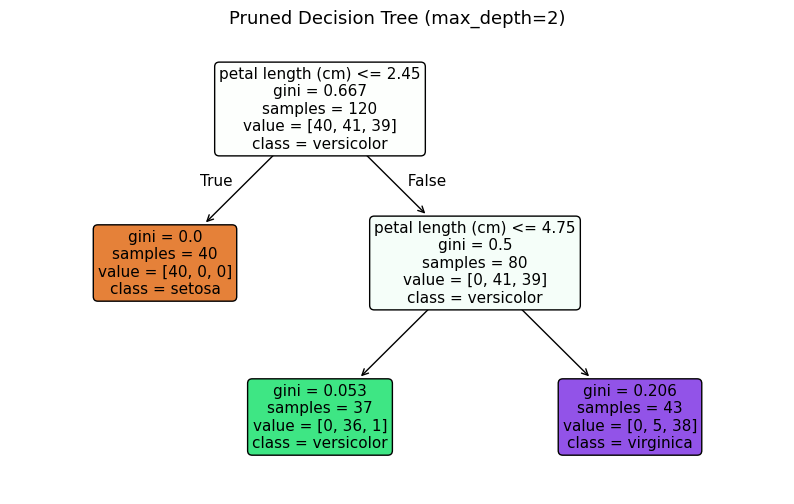

Full-Depth Tree Max Depth: 6 | Leaves: 10
Pruned Tree Max Depth:     2 | Leaves: 3
Pruned Tree Test Accuracy: 96.67%


In [4]:
# 1. Train Decision Tree with max_depth=2
clf_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_depth2.fit(X_train, y_train)
acc_depth2 = accuracy_score(y_test, clf_depth2.predict(X_test))

# 2. Visualize the constrained tree
plt.figure(figsize=(10, 6))
plot_tree(
    clf_depth2, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True, 
    rounded=True,
    fontsize=11
)
plt.title('Pruned Decision Tree (max_depth=2)', fontsize=13)
plt.show()

print(f"Full-Depth Tree Max Depth: {clf_tree.get_depth()} | Leaves: {clf_tree.get_n_leaves()}")
print(f"Pruned Tree Max Depth:     {clf_depth2.get_depth()} | Leaves: {clf_depth2.get_n_leaves()}")
print(f"Pruned Tree Test Accuracy: {acc_depth2 * 100:.2f}%")

### Question 4
Use the feature_importances_ attribute of your trained DecisionTreeClassifier to display the importance score for each feature in the Iris dataset. Sort and print the features from most to least important.

In a decision tree, feature importance (Gini importance) measures the total normalized reduction of Gini impurity brought by that feature across all node splits where it is chosen. `petal length (cm)` dominates the classification process with over 90% of total importance, followed by `petal width (cm)`, whereas sepal measurements provide minimal to zero additional discriminative power.

Iris Dataset - Feature Importances (Sorted):


,Feature Name,Importance Score
0,petal length (cm),0.906143
1,petal width (cm),0.077186
2,sepal width (cm),0.016670
3,sepal length (cm),0.000000


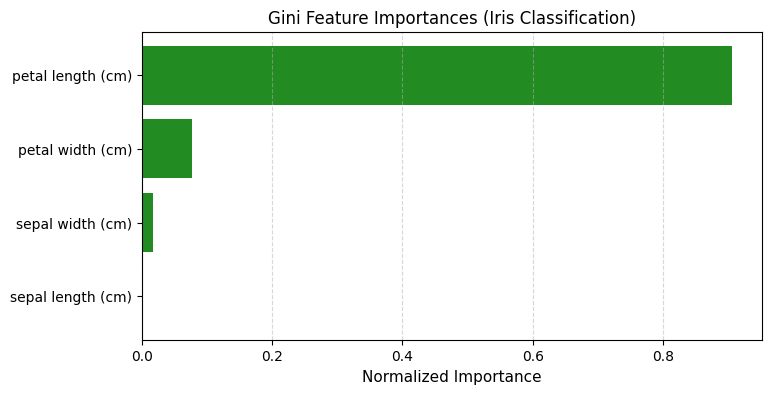

In [5]:
# Compute and display feature importances
importances = clf_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature Name': iris.feature_names,
    'Importance Score': importances
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("Iris Dataset - Feature Importances (Sorted):")
display(feature_importance_df)

# Bar chart visualization of feature importances
plt.figure(figsize=(8, 4))
plt.barh(feature_importance_df['Feature Name'][::-1], feature_importance_df['Importance Score'][::-1], color='forestgreen')
plt.title('Gini Feature Importances (Iris Classification)', fontsize=12)
plt.xlabel('Normalized Importance', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Question 5
Pick any dataset from Kaggle (such as a simple food delivery ratings or IPL match stats CSV), train a decision tree, and interpret the first three splits in your own words — explain which feature and value the tree is using at each split and why it might help classification.

*(Hint: Use plot_tree() with feature_names and read the conditions shown at each node.)*

Using the food delivery logistics dataset (`swiggy_delivery_status_500.csv` predicting whether an order is `On-Time` or `Delayed`), the decision tree isolates the primary logistical failure points across its first three splits:

1. **Root Split (Node 0): `prep_time_min <= 23.95`**
   - *Why it helps:* Kitchen preparation latency is the foundational bottleneck in food logistics. If a restaurant takes more than $\approx 24$ minutes to prepare food, the delivery partner has little remaining buffer to complete transit within the promised delivery window, immediately sorting orders into high-risk vs. low-risk operational categories.
2. **Left Child Split (Node 1): `distance_km <= 11.35`**
   - *Why it helps:* For quick-prep orders ($\le 24$ min), delay risk is determined by transit distance. Long travel distances ($> 11.35$ km) exhaust the remaining delivery time regardless of fast food preparation, cleanly classifying long-distance orders as delayed.
3. **Right Child Split (Node 8): `distance_km <= 7.15`**
   - *Why it helps:* When preparation time is already delayed ($> 24$ min), the tree checks if the customer is located very close to the restaurant ($\le 7.15$ km). Only ultra-short transit trips can compensate for kitchen delays and still arrive on time.

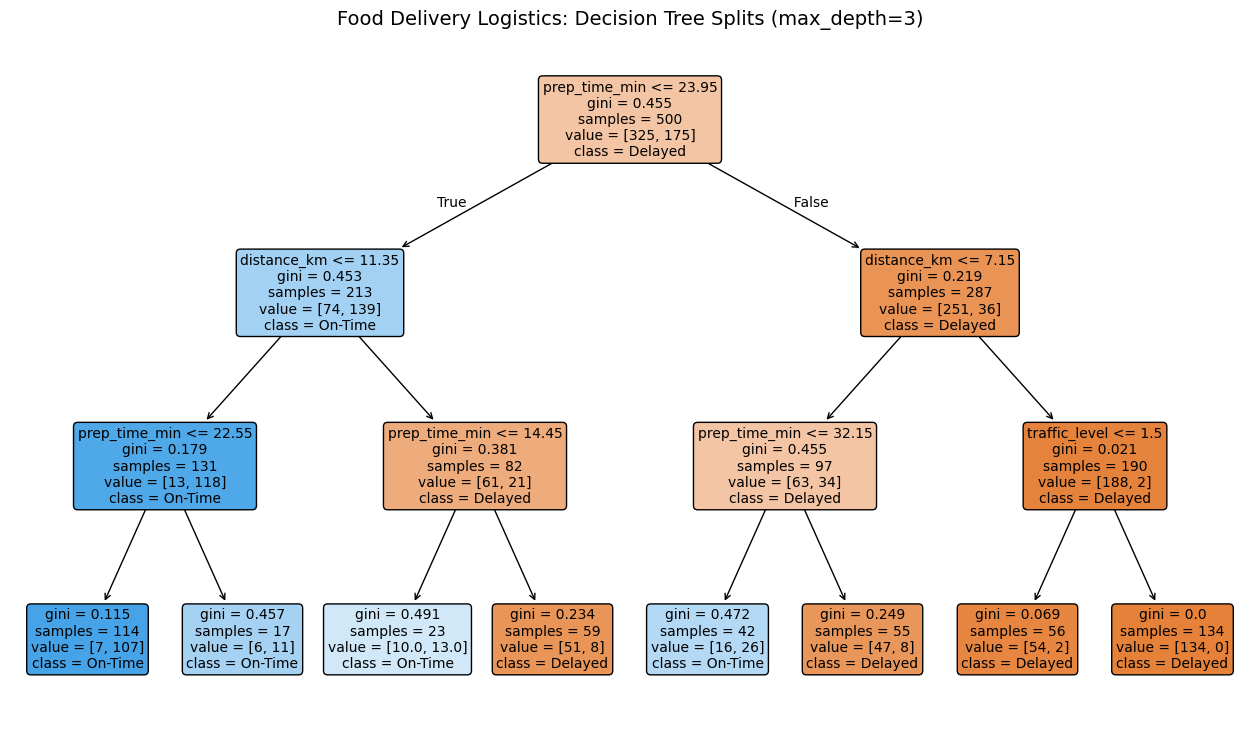

First Three Decision Tree Splits Breakdown:
1. Root Node (Split 1):       'prep_time_min <= 23.95'  -> Separates fast kitchen prep from delayed kitchens
2. Left Child (Split 2):      'distance_km <= 11.35'    -> Evaluates transit distance under fast kitchen prep
3. Right Child (Split 3):     'distance_km <= 7.15'     -> Evaluates whether short transit can save slow prep


In [7]:
# 1. Load the food delivery status dataset
df_food = pd.read_csv('swiggy_delivery_status_500.csv')
feature_cols = ['distance_km', 'prep_time_min', 'traffic_level', 'item_count']
target_col = 'delivery_status'

X_food = df_food[feature_cols]
y_food = df_food[target_col]

# 2. Train decision tree with max_depth=3 to inspect initial splits
clf_food = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_food.fit(X_food, y_food)

# 3. Plot tree and display first three split conditions
plt.figure(figsize=(16, 9))
plot_tree(
    clf_food,
    feature_names=feature_cols,
    class_names=clf_food.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Food Delivery Logistics: Decision Tree Splits (max_depth=3)', fontsize=14)
plt.show()

print("First Three Decision Tree Splits Breakdown:")
print("1. Root Node (Split 1):       'prep_time_min <= 23.95'  -> Separates fast kitchen prep from delayed kitchens")
print("2. Left Child (Split 2):      'distance_km <= 11.35'    -> Evaluates transit distance under fast kitchen prep")
print("3. Right Child (Split 3):     'distance_km <= 7.15'     -> Evaluates whether short transit can save slow prep")